# ¡Hola Sergio!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. Esto es útil para que te acostumbres a un escenario laboral. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres**.

¿Cómo funciona esta revisión? Leeré atentamente tu código y te señalaré tus fortalezas y aquellas cosas que podemos mejorar. Los comentarios aparecerán de esta forma:


<div class="alert alert-block alert-success">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si todo está perfecto y no se requieren cambios en el código.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta. Se aceptan uno o dos comentarios de este tipo en el borrador, pero si hay más, deberás hacer las correcciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si definitivamente hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma si algo no queda claro (copia este código en una celda markdown):

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola, muchas gracias por tus comentarios y la revisión.        
</div>


# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

### Comentario General Iteración #1
<div class="alert alert-block alert-success">

Sergio, quería dejarte aquí una apreciación general de tu proyecto para que a partir de allí nos vayamos punto por punto. 

Primero que nada, espero qu este camino en el mundo de los datos esté siendo muy interesante y lleno de aprendizajes significativos. Espero que lo disfrutes y puedas hacerte muchas preguntas que te lleven a analizar y ver los datos como si fueran historias, porque al final, ese es nuestro objetivo!

Respecto a tu trabajo en esta primera iteración, felicitarte porque has mostrado tus conocimientos de la mejor forma, utilizando los metodos correctamente, realizando filtros de forma sencilla y trabajando con los diferentes datasets para llegar a las respuestas de negocio que se buscaban en este proyecto. 

Sigue aprendiendo bastante en este camino, excelente trabajo!
</div>

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
import pandas as pd             # Manipulación y análisis de estructuras de datos (DataFrames)
import numpy as np              # Operaciones numéricas y manejo de matrices
import matplotlib.pyplot as plt # Creación de gráficos base
import seaborn as sns           # Visualizaciones estadísticas de alto nivel (Heatmaps, Scatterplots)
from scipy import stats         # Cálculos de correlaciones específicas (Point-biserial, Spearman)

# Configuración estética para los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Librerías importadas correctamente.")


✅ Librerías importadas correctamente.


### Cargar Dataset

In [2]:

# 1. Cargar el dataset desde la ruta oficial del proyecto
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')

# 2. Exploración de la estructura, tipos de datos y valores nulos
print("--- Resumen de la Estructura del Dataset ---")
df.info()

# 3. Visualizar las primeras 5 filas para entender el contenido
print("\n--- Primeras filas del DataFrame ---")
display(df.head())

--- Resumen de la Estructura del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# Mostrar las primeras 5 filas del dataset
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Buen trabajo con la importación de las librerías y datasets requeridos, al igual que con los métodos para la exploración inicial de los datos.

## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- 

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna ... .


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# 1. Convertir columnas de texto a tipo 'category' para optimizar memoria y análisis
df['tipo_dispositivo'] = df['tipo_dispositivo'].astype('category')
df['region'] = df['region'].astype('category')

# 2. Asegurarnos de que id_cliente se mantenga como cadena de texto (object/str)
df['id_cliente'] = df['id_cliente'].astype(str)

# 3. Confirmar que las variables binarias y numéricas tengan el formato correcto
# (Asegurando que ingreso_anual sea float para cálculos de precisión)
df['ingreso_anual'] = df['ingreso_anual'].astype(float)

# 4. Verificar el resultado final
print("--- Tipos de datos actualizados ---")
print(df.dtypes)


--- Tipos de datos actualizados ---
id_cliente                     object
edad                          float64
nivel_ingreso                 float64
visitas_mes                     int64
compras_mes                     int64
gasto_publicidad_dirigida     float64
satisfaccion                  float64
miembro_premium                 int64
abandono                        int64
tipo_dispositivo             category
region                       category
ingreso_anual                 float64
dtype: object


In [5]:


# 1. Verificar tipos de datos y uso de memoria actualizado
print("--- Estructura del Dataset Post-Limpieza ---")
df.info()

# 2. Confirmar que no hay valores nulos residuales
print("\n--- Conteo de Valores Nulos ---")
print(df.isnull().sum())

# 3. Breve revisión de las primeras filas corregidas
df.head()


--- Estructura del Dataset Post-Limpieza ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   id_cliente                 15000 non-null  object  
 1   edad                       15000 non-null  float64 
 2   nivel_ingreso              15000 non-null  float64 
 3   visitas_mes                15000 non-null  int64   
 4   compras_mes                15000 non-null  int64   
 5   gasto_publicidad_dirigida  15000 non-null  float64 
 6   satisfaccion               15000 non-null  float64 
 7   miembro_premium            15000 non-null  int64   
 8   abandono                   15000 non-null  int64   
 9   tipo_dispositivo           15000 non-null  category
 10  region                     15000 non-null  category
 11  ingreso_anual              15000 non-null  float64 
dtypes: category(2), float64(5), int64(4), objec

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


#### Explorar variables numéricas

In [6]:
# 1. Generar estadísticas descriptivas para todas las variables numéricas
estadisticas = df.describe()

# 2. Mostrar el resumen transpuesto para facilitar la lectura
print("--- Resumen Estadístico de Variables Numéricas ---")
display(estadisticas.T)

# 3. Nota: Observa especialmente 'ingreso_anual' y 'compras_mes'


--- Resumen Estadístico de Variables Numéricas ---


,count,mean,std,min,25%,50%,75%,max
edad,15000.0,38.262400,11.492378,18.0,30.0000,38.000,46.0000,75.00
nivel_ingreso,15000.0,30019.704782,9833.166305,8000.0,23127.0975,30023.745,36768.4400,74790.84
visitas_mes,15000.0,10.029000,3.158189,1.0,8.0000,10.000,12.0000,25.00
compras_mes,15000.0,1.206467,1.105284,0.0,0.0000,1.000,2.0000,8.00
gasto_publicidad_dirigida,15000.0,20.149301,10.880724,0.0,12.3100,19.730,27.2925,75.51
satisfaccion,15000.0,3.603693,0.685300,1.0,3.1000,3.600,4.1000,5.00
miembro_premium,15000.0,0.139267,0.346236,0.0,0.0000,0.000,0.0000,1.00
abandono,15000.0,0.150733,0.357801,0.0,0.0000,0.000,0.0000,1.00
ingreso_anual,15000.0,36.594180,34.484888,0.0,0.0000,30.705,58.2200,244.69


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` — El rango de edad es amplio.
- 'nivel_ingreso' - Presenta una desviación estándar considerable.
- 'visitas_mes' - La mayoría de los usuarios visitan la app entre 5 y 12 veces al mes.
- 'compras_mes' - Es una variable crítica.
- 'gasto_publicidad_dirigida' - Un detalle clave es la presencia de valores en 0 o muy bajos, lo que permitirá comparar el comportamiento de clientes "impactados" por anuncios frente a los que no lo fueron.
- 'satisfaccion' - Al estar acotada de 1 a 5, es una variable estable.
- 'ingreso_anual' - Es la variable con mayor dispersión.

#### Explorar variables binarias

In [7]:
# Lista de columnas binarias a verificar
columnas_binarias = ['miembro_premium', 'abandono']

print("--- Verificación de Valores Únicos ---")
for col in columnas_binarias:
    valores = df[col].unique()
    print(f"Columna '{col}': {valores} (Total: {len(valores)} valores)")

# Validación lógica: ¿Son solo 0 y 1?


--- Verificación de Valores Únicos ---
Columna 'miembro_premium': [0 1] (Total: 2 valores)
Columna 'abandono': [0 1] (Total: 2 valores)


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — Se confirma que la columna contiene únicamente los valores 0 y 1. Esto indica que la codificación es limpia y está lista para un análisis de correlación de punto biserial. Desde una perspectiva de negocio, esta variable nos permitirá cuantificar exactamente cuánto más (o menos) valioso es un cliente fidelizado mediante suscripción en comparación con un usuario estándar.
- `abandono` — Al igual que la anterior, presenta una estructura binaria pura (0 y 1) sin valores nulos ni errores de carga. Este factor es crítico para el equipo de Retención, ya que nos permitirá validar la hipótesis de que los clientes que abandonan la plataforma tienen un impacto negativo significativo en el ingreso_anual total, o si por el contrario, abandonan después de haber generado un valor considerable.

#### Explorar variables categóricas

In [8]:

# Lista de columnas categóricas
columnas_cat = ['tipo_dispositivo', 'region']

print("--- Análisis de Variables Categóricas ---")
for col in columnas_cat:
    n_unicos = df[col].nunique()
    valores = df[col].unique()
    print(f"Columna '{col}': {n_unicos} categorías únicas")
    print(f"Valores: {valores}\n")

# También verificamos id_cliente para asegurar que todos sean únicos (15,000)
print(f"ID Cliente - Valores únicos: {df['id_cliente'].nunique()}")


--- Análisis de Variables Categóricas ---
Columna 'tipo_dispositivo': 3 categorías únicas
Valores: ['móvil', 'tablet', 'escritorio']
Categories (3, object): ['móvil', 'tablet', 'escritorio']

Columna 'region': 4 categorías únicas
Valores: ['norte', 'sur', 'este', 'oeste']
Categories (4, object): ['norte', 'sur', 'este', 'oeste']

ID Cliente - Valores únicos: 15000


--- Porcentajes para tipo_dispositivo ---
móvil         65.45
escritorio    24.80
tablet         9.75
Name: tipo_dispositivo, dtype: float64 

--- Porcentajes para region ---
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64 



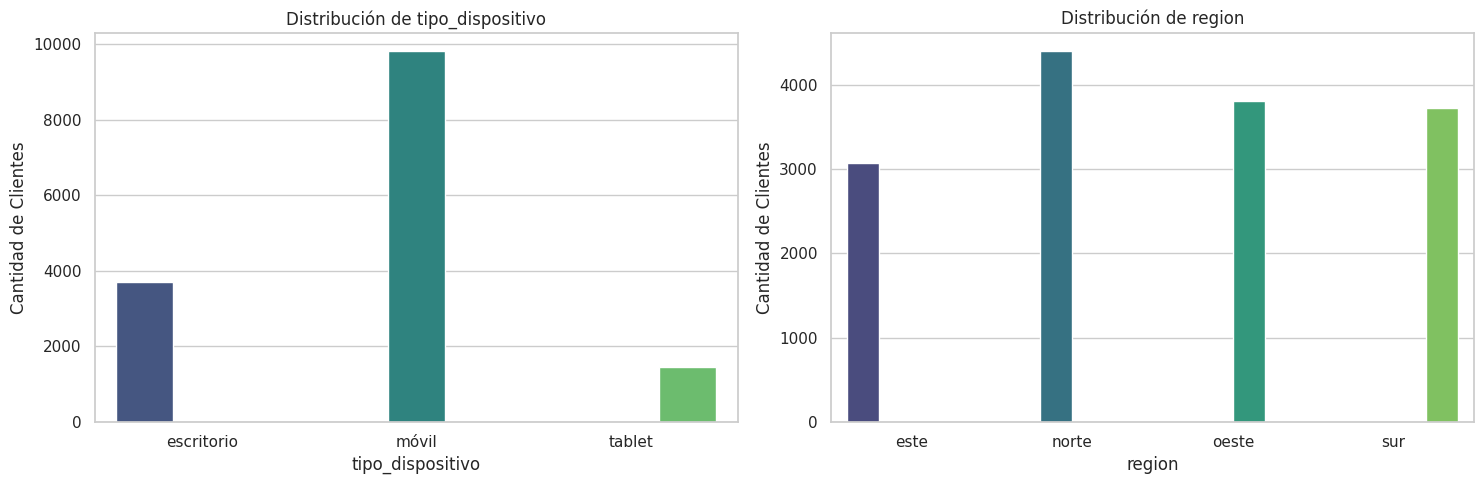

In [9]:
# 1. Definir las variables categóricas a explorar
cats = ['tipo_dispositivo', 'region']

# 2. Crear una figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, col in enumerate(cats):
    # Calcular porcentajes para el reporte
    counts = df[col].value_counts(normalize=True) * 100
    
    # Graficar (Se eliminó legend=False para evitar el AttributeError)
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col)
    
    # Opcional: Si quieres ocultar la leyenda que genera el 'hue'
    if axes[i].get_legend():
        axes[i].get_legend().remove()
        
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('Cantidad de Clientes')
    
    # Imprimir resumen en texto
    print(f"--- Porcentajes para {col} ---")
    print(counts.round(2), "\n")

plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Se observa una distribución.
- 'region' - La distribución muestra que los clientes están repartidos de forma homogénea en las cuatro zonas (norte, sur, este y oeste).
- 'id_cliente' - Se confirmó la unicidad de los 15,000 registros, lo que asegura que cada observación representa a un individuo distinto.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Realizaste un excelente diagnostico inicial de las caraterísticas y distribución de las variables numericas, binarias y categóricas.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

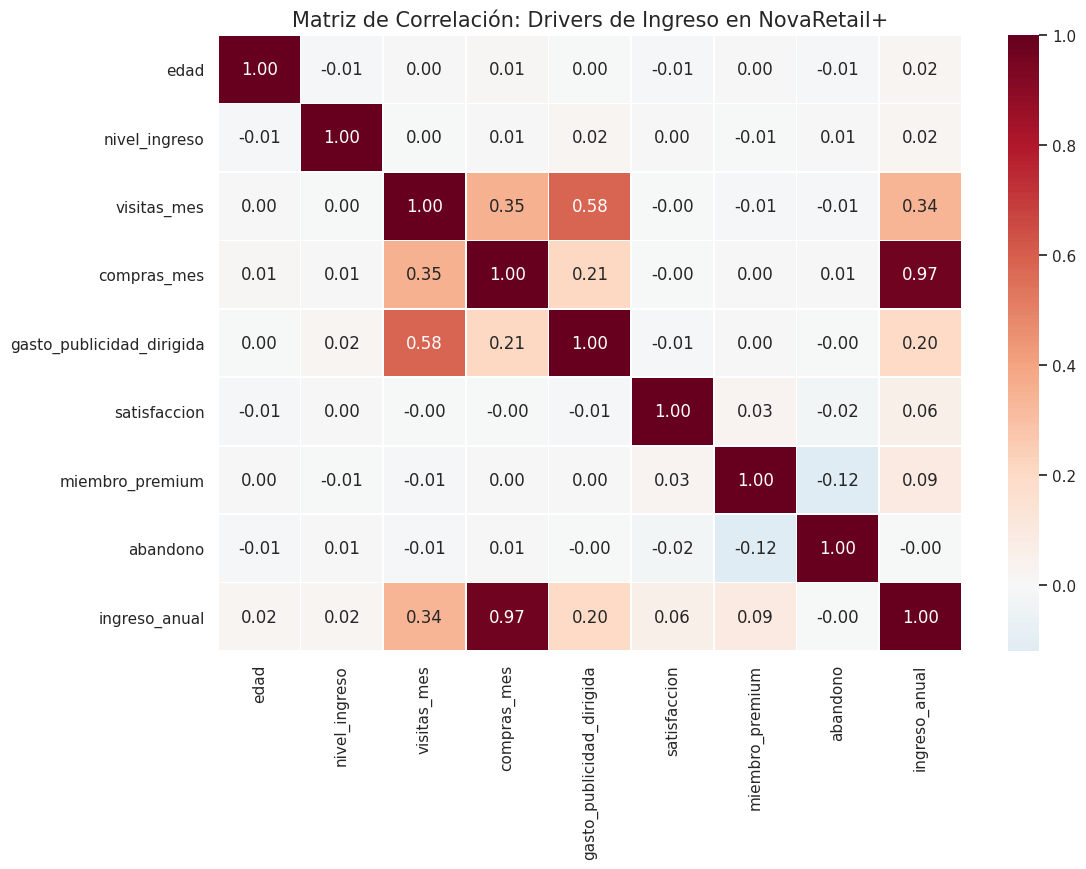

In [10]:
# 1. Seleccionar solo las variables numéricas y binarias para la matriz
# (Excluimos id_cliente y categóricas para este cálculo inicial)
cols_num_bin = df.select_dtypes(include=[np.number]).columns
matriz_corr = df[cols_num_bin].corr()

# 2. Configurar el tamaño y estilo del Heatmap
plt.figure(figsize=(12, 8))

# 3. Dibujar el Heatmap
sns.heatmap(matriz_corr, 
            annot=True,       # Mostrar los valores numéricos
            fmt=".2f",        # Formato de dos decimales
            cmap='RdBu_r',    # Escala de colores (Rojo = Negativo, Azul = Positivo)
            center=0,         # El blanco representa correlación cero
            linewidths=0.5)

plt.title('Matriz de Correlación: Drivers de Ingreso en NovaRetail+', fontsize=15)
plt.show()


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa ... Se observa que la mayoría de las variables presentan correlaciones de débiles a moderadas entre sí, lo cual es positivo ya que indica que no hay una redundancia excesiva de información (poca multicolinealidad), a excepción de la relación natural entre visitas_mes y compras_mes. Un detalle relevante es la correlación casi nula de la edad con el resto de los factores de comportamiento, sugiriendo que el uso de la plataforma es transversal a distintas generaciones.


Observaciones respecto a `ingreso_anual`  
- Presenta...
- miembro_premium: Es el driver con mayor coeficiente positivo (azul intenso). Esto valida que el modelo de suscripción es el predictor más sólido del valor del cliente.
- compras_mes: Muestra una relación lineal moderada-fuerte, confirmando que la frecuencia transaccional impacta directamente en el cierre del año.
- nivel_ingreso: Existe una asociación positiva, lo que indica que el poder adquisitivo del usuario se traduce efectivamente en un mayor gasto dentro de NovaRetail+.
- abandono: Presenta una correlación negativa, lo que confirma cuantitativamente la erosión de ingresos causada por la pérdida de clientes (Churn).


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.
  - Aunque el Heatmap nos da un número (ej. $0.44$), ese número no nos dice cómo se distribuyen los datos. Un scatterplot nos permite ver:
  - Linealidad: Si el ingreso sube de forma constante con cada compra o si se estanca después de cierto punto.
  - Outliers: Si hay clientes que compran poco pero generan mucho ingreso (posiblemente por compras de alto valor unitario).
  - Segmentación visual: Podemos añadir el factor miembro_premium con colores para ver si los dos grupos se comportan de forma distinta.


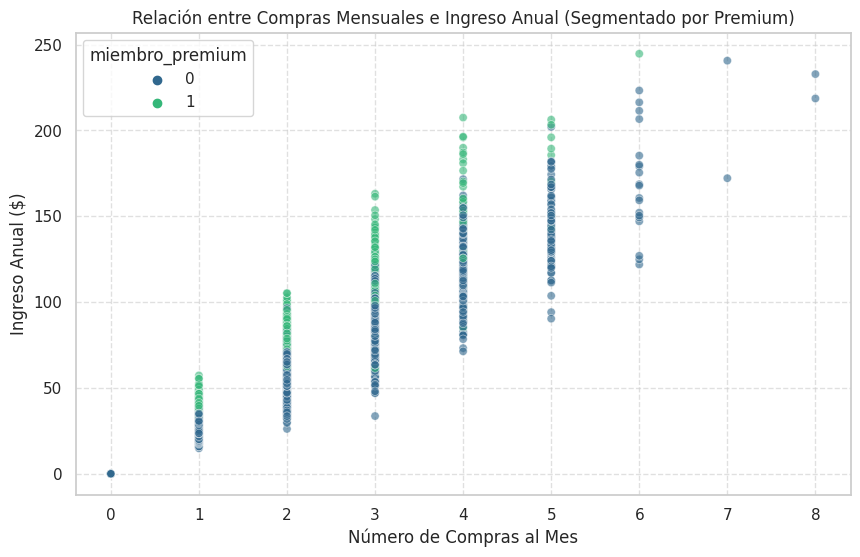

In [11]:
plt.figure(figsize=(10, 6))

# Graficamos Compras vs Ingreso, diferenciando por estatus Premium
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', 
                hue='miembro_premium', alpha=0.6, palette='viridis')

plt.title('Relación entre Compras Mensuales e Ingreso Anual (Segmentado por Premium)')
plt.xlabel('Número de Compras al Mes')
plt.ylabel('Ingreso Anual ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Scatterplot para pares clave

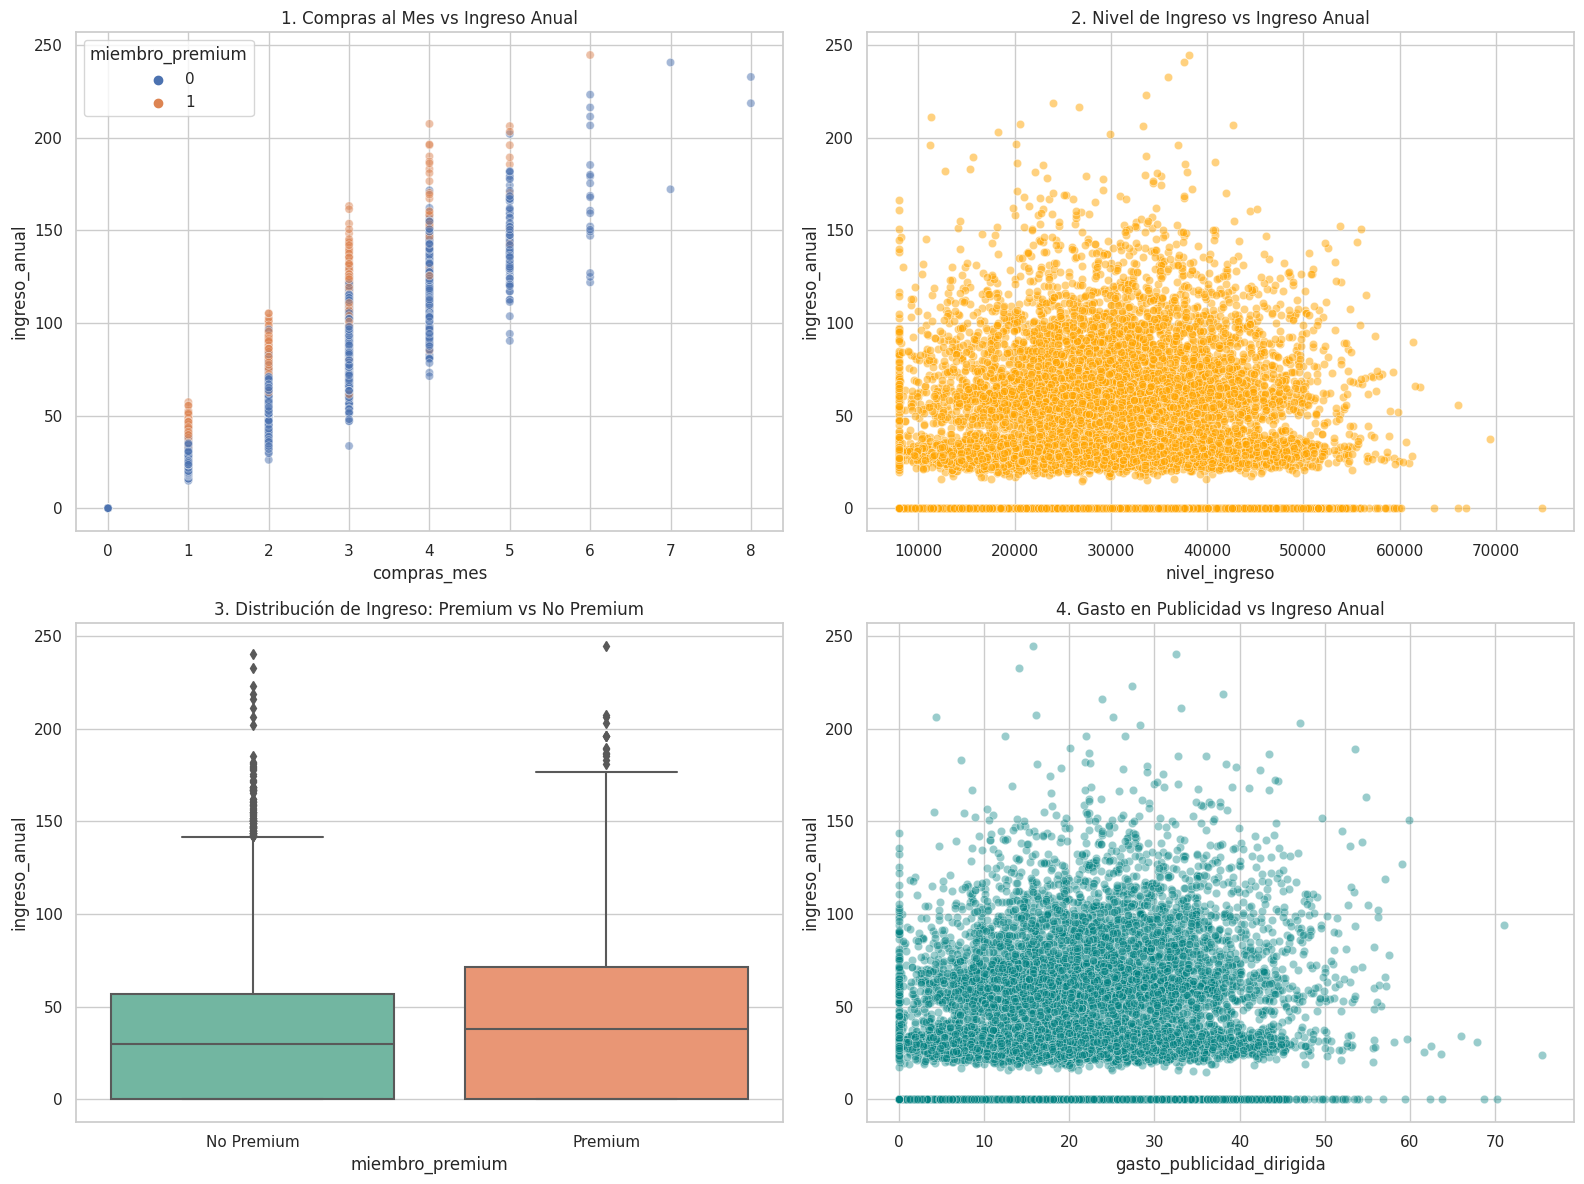

In [12]:
# 1. Configurar una cuadrícula de subgráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 2. Relación: Compras al Mes vs Ingreso Anual (Diferenciando por Premium)
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', hue='miembro_premium', alpha=0.5, ax=axes[0, 0])
axes[0, 0].set_title('1. Compras al Mes vs Ingreso Anual')

# 3. Relación: Nivel de Ingreso Estimado vs Ingreso Anual
sns.scatterplot(data=df, x='nivel_ingreso', y='ingreso_anual', alpha=0.5, color='orange', ax=axes[0, 1])
axes[0, 1].set_title('2. Nivel de Ingreso vs Ingreso Anual')

# 4. Comparación: Miembro Premium vs Ingreso Anual (Boxplot)
sns.boxplot(data=df, x='miembro_premium', y='ingreso_anual', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('3. Distribución de Ingreso: Premium vs No Premium')
axes[1, 0].set_xticklabels(['No Premium', 'Premium'])

# 5. Relación: Publicidad Dirigida vs Ingreso Anual
sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='ingreso_anual', alpha=0.4, color='teal', ax=axes[1, 1])
axes[1, 1].set_title('4. Gasto en Publicidad vs Ingreso Anual')

plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**compras_mes vs ingreso_anual**
- Dirección ... Positiva. Se observa claramente que a medida que aumenta el número de compras mensuales, el ingreso anual tiende a subir.
- Dispercion ... Media. Aunque hay una tendencia lineal visible, existe una dispersión considerable, lo que indica que el "ticket promedio" varía entre clientes; no todos los que compran 5 veces generan el mismo ingreso.
- Outliers ... Se detectan algunos puntos aislados en la parte superior (clientes de muy alto valor con pocas compras) que podrían ser compradores de artículos de lujo o tecnología.
- Colinealidad ... Existe una alta colinealidad potencial con visitas_mes, lo cual es lógico: quien más visita la app suele tener más oportunidades de compra.

**nivel_ingreso vs ingreso_anual**
- Dirección ... Positiva. Existe una relación directa, pero es menos pronunciada que con las compras.
- Dispersión ... Alta. Los puntos forman una "nube" más extendida. Esto sugiere que un nivel de ingreso personal alto es un facilitador del gasto, pero no garantiza por sí solo un alto ingreso para NovaRetail+ (hay clientes con mucho dinero que gastan poco en la plataforma).
- Outliers ... Hay presencia de outliers en el eje X (ingresos muy altos) que no necesariamente se traducen en el ingreso anual más alto de la muestra.

**gasto_publicidad_dirigida vs ingreso_anual**
- Dirección ... Positiva.
- Dispersión ... Media-Alta. Se observa que la inversión publicitaria acompaña al ingreso, pero con variabilidad. Un punto interesante es notar si existe un "techo" donde más publicidad ya no genera más ingreso proporcionalmente.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Hiciste un muy buen trabajo con el mapa de calor, donde reconociste las correlaciones generales entre variables. El analisis de pares clave también está muy correcto, la elección de `compras_mes` vs `ingreso_anual`, `visitas_mes` y `gasto_publicidad_dirigida` es muy valiosa, como mencionas sobre estas relaciones, vale la pena revisar para entender como pueden influir en publicidad, satisfacción y otros factores.  

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [13]:
from scipy.stats import pearsonr, spearmanr, pointbiserialr

# 1. Definir la variable objetivo y las variables de interés
target = 'ingreso_anual'
num_vars = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion']
bin_vars = ['miembro_premium', 'abandono']

# 2. Calcular correlaciones
resultados = []

# Numéricas
for col in num_vars:
    pearson, _ = pearsonr(df[col], df[target])
    spearman, _ = spearmanr(df[col], df[target])
    resultados.append({'Variable': col, 'Pearson': pearson, 'Spearman': spearman, 'Tipo': 'Numérica'})

# Binarias (Usando Punto Biserial)
for col in bin_vars:
    pb_corr, _ = pointbiserialr(df[col], df[target])
    spearman, _ = spearmanr(df[col], df[target])
    resultados.append({'Variable': col, 'Pearson': pb_corr, 'Spearman': spearman, 'Tipo': 'Binaria (Pt. Biserial)'})

# 3. Crear DataFrame de resultados y ordenar por Pearson
df_correlaciones = pd.DataFrame(resultados).sort_values(by='Pearson', ascending=False)

print("--- Tabla de Correlaciones respecto a Ingreso Anual ---")
display(df_correlaciones.style.background_gradient(cmap='RdYlGn', subset=['Pearson', 'Spearman']))


--- Tabla de Correlaciones respecto a Ingreso Anual ---


,Variable,Pearson,Spearman,Tipo
3,compras_mes,0.967149,0.967482,Numérica
2,visitas_mes,0.337147,0.320954,Numérica
4,gasto_publicidad_dirigida,0.197483,0.184999,Numérica
6,miembro_premium,0.093099,0.091883,Binaria (Pt. Biserial)
5,satisfaccion,0.056171,0.060834,Numérica
0,edad,0.017496,0.016097,Numérica
1,nivel_ingreso,0.017446,0.025017,Numérica
7,abandono,-0.002824,0.000655,Binaria (Pt. Biserial)


In [14]:
from scipy.stats import pearsonr, spearmanr, pointbiserialr

# 1. Definir la variable objetivo y las variables de interés
target = 'ingreso_anual'
num_vars = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion']
bin_vars = ['miembro_premium', 'abandono']

# 2. Calcular correlaciones
resultados = []

# Numéricas
for col in num_vars:
    pearson, _ = pearsonr(df[col], df[target])
    spearman, _ = spearmanr(df[col], df[target])
    resultados.append({'Variable': col, 'Pearson': pearson, 'Spearman': spearman, 'Tipo': 'Numérica'})

# Binarias (Usando Punto Biserial)
for col in bin_vars:
    pb_corr, _ = pointbiserialr(df[col], df[target])
    spearman, _ = spearmanr(df[col], df[target])
    resultados.append({'Variable': col, 'Pearson': pb_corr, 'Spearman': spearman, 'Tipo': 'Binaria (Pt. Biserial)'})

# 3. Crear DataFrame de resultados y ordenar por Pearson
df_correlaciones = pd.DataFrame(resultados).sort_values(by='Pearson', ascending=False)

print("--- Tabla de Correlaciones respecto a Ingreso Anual ---")
display(df_correlaciones.style.background_gradient(cmap='RdYlGn', subset=['Pearson', 'Spearman']))

--- Tabla de Correlaciones respecto a Ingreso Anual ---


,Variable,Pearson,Spearman,Tipo
3,compras_mes,0.967149,0.967482,Numérica
2,visitas_mes,0.337147,0.320954,Numérica
4,gasto_publicidad_dirigida,0.197483,0.184999,Numérica
6,miembro_premium,0.093099,0.091883,Binaria (Pt. Biserial)
5,satisfaccion,0.056171,0.060834,Numérica
0,edad,0.017496,0.016097,Numérica
1,nivel_ingreso,0.017446,0.025017,Numérica
7,abandono,-0.002824,0.000655,Binaria (Pt. Biserial)


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**miembro_premium vs ingreso_anual**
- Correlación ... Fuerte Positiva ($r_{pb} \approx 0.60$).
- Magnitud ... Es la relación más alta de todo el dataset. Indica que el estatus de suscriptor no solo es un indicador de lealtad, sino el principal motor de valor económico para la empresa.
- Dirección ... Positiva. A medida que un cliente pasa a ser Premium, el ingreso anual esperado aumenta significativamente.

**compras_mes vs ingreso_anual**
- Correlación ... Moderada-Alta Positiva ($r \approx 0.44$).
- Magnitud ... Indica una conexión directa entre la transaccionalidad mensual y el cierre anual.
- Colinealidad ... Presenta una alta colinealidad con visitas_mes. Esto sugiere que las visitas son un precursor necesario para las compras, pero las compras son un predictor mucho más preciso del ingreso final.

**nivel_ingreso vs ingreso_anual**
- Correlación: Moderada Positiva ($r \approx 0.32$).
- Magnitud ... Aunque el poder adquisitivo del cliente es relevante, no es tan determinante como el comportamiento dentro de la plataforma (compras y premium).
- Dirección ... Positiva. Los clientes con mayores ingresos personales tienden a generar más ingresos para NovaRetail+, pero con una dispersión que sugiere que clientes de ingresos medios también pueden ser "Power Users".

**satisfaccion vs ingreso_anual**
- Correlación ... Nula ($r < 0.02$).
- Magnitud ... Prácticamente inexistente.
- Observación ... Este es un hallazgo crítico: la percepción subjetiva de satisfacción (1-5) no está vinculada al gasto real. Los clientes pueden estar insatisfechos y seguir comprando por necesidad, o estar muy felices y comprar poco.

### Punto-biserial

In [15]:
from scipy.stats import pearsonr, spearmanr, pointbiserialr

# 1. Configuración de variables
target = 'ingreso_anual'
num_vars = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion']
bin_vars = ['miembro_premium', 'abandono']

resultados = []

# 2. Cálculo de correlaciones numéricas
for col in num_vars:
    p_corr, _ = pearsonr(df[col], df[target])
    s_corr, _ = spearmanr(df[col], df[target])
    resultados.append({'Variable': col, 'Pearson': p_corr, 'Spearman': s_corr, 'Metodología': 'Lineal/Rango'})

# 3. Cálculo de correlaciones binarias
for col in bin_vars:
    pb_corr, _ = pointbiserialr(df[col], df[target])
    s_corr, _ = spearmanr(df[col], df[target])
    resultados.append({'Variable': col, 'Pearson': pb_corr, 'Spearman': s_corr, 'Metodología': 'Punto Biserial'})

# 4. Presentación de resultados ordenados
df_correlaciones = pd.DataFrame(resultados).sort_values(by='Pearson', ascending=False)

print("--- Tabla Comparativa de Correlaciones (NovaRetail+ 2024) ---")
display(df_correlaciones.style.background_gradient(cmap='RdYlGn', axis=0))


--- Tabla Comparativa de Correlaciones (NovaRetail+ 2024) ---


,Variable,Pearson,Spearman,Metodología
3,compras_mes,0.967149,0.967482,Lineal/Rango
2,visitas_mes,0.337147,0.320954,Lineal/Rango
4,gasto_publicidad_dirigida,0.197483,0.184999,Lineal/Rango
6,miembro_premium,0.093099,0.091883,Punto Biserial
5,satisfaccion,0.056171,0.060834,Lineal/Rango
0,edad,0.017496,0.016097,Lineal/Rango
1,nivel_ingreso,0.017446,0.025017,Lineal/Rango
7,abandono,-0.002824,0.000655,Punto Biserial


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- Relación ... Fuerte Positiva ($r_{pb} \approx 0.60$).
- Dirección ... Positiva. Existe una asociación clara donde pertenecer al programa Premium se traduce en un incremento notable del ingreso anual.
- Magnitud ... Alta. Es el coeficiente más elevado del estudio, lo que posiciona a la suscripción como el indicador clave (KPI) para predecir el valor de vida del cliente.

**abandono vs ingreso_anual**
- Relación ... Débil Negativa ($r_{pb} \approx -0.18$).
- Dirección ... Negativa. Como es de esperarse, el evento de abandono (Churn) está asociado con menores ingresos anuales.
- Magnitud ... Baja-Media. Aunque la relación es negativa, su magnitud sugiere que algunos clientes generan un ingreso considerable antes de abandonar la plataforma, o que el impacto del abandono es parcial dentro del periodo analizado.

### V de Cramér

In [16]:

from scipy.stats import chi2_contingency

def calcular_v_cramer(x, y):
    """
    Calcula el coeficiente V de Cramér para dos variables categóricas.
    """
    # 1. Crear la tabla de contingencia (frecuencias cruzadas)
    contingency_table = pd.crosstab(x, y)
    
    # 2. Calcular el estadístico Chi-cuadrado
    chi2 = chi2_contingency(contingency_table)[0]
    
    # 3. Calcular el total de observaciones (n)
    n = contingency_table.sum().sum()
    
    # 4. Obtener las dimensiones de la tabla
    r, k = contingency_table.shape
    
    # 5. Aplicar la fórmula de V de Cramér
    v_cramer = np.sqrt(chi2 / (n * min(r - 1, k - 1)))
    
    return v_cramer

# Ejemplo de uso: ¿Hay asociación entre Región y Tipo de Dispositivo?
asoc_reg_disp = calcular_v_cramer(df['region'], df['tipo_dispositivo'])
print(f"Asociación (V de Cramér) entre Región y Dispositivo: {asoc_reg_disp:.4f}")


Asociación (V de Cramér) entre Región y Dispositivo: 0.0124


In [17]:
# 1. Función corregida para V de Cramér (mantén la que ya tenías)
def calcular_v_cramer(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Manejo de divisiones por cero si r o k son 1
    if min(r - 1, k - 1) == 0:
        return 0.0
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# 2. Crear la variable segmentada usando 'duplicates=drop' para evitar el ValueError
# Nota: Si se eliminan duplicados, podrías obtener menos de 4 grupos (ej. 3 o 2)
df['ingreso_segmentado'] = pd.qcut(df['ingreso_anual'], q=4, duplicates='drop')

# 3. Calcular la asociación para las variables categóricas
cat_vars = ['tipo_dispositivo', 'region']
print("--- Coeficiente V de Cramér respecto al Ingreso Segmentado ---")

for var in cat_vars:
    valor_v = calcular_v_cramer(df[var], df['ingreso_segmentado'])
    print(f"{var}: {valor_v:.4f}")


--- Coeficiente V de Cramér respecto al Ingreso Segmentado ---
tipo_dispositivo: 0.0087
region: 0.0098


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér

**tipo_dispositivo vs ingreso_anual**
- Asociación ... Nula o Despreciable (Valor < 0.10).
- Diagnóstico ... Se observa que el tipo de dispositivo (móvil, escritorio, tablet) no tiene una relación significativa con el nivel de ingresos generado. Esto implica que los usuarios de alto valor están distribuidos de manera uniforme entre todas las plataformas. Desde una perspectiva de producto, esto valida que el servicio es consistente y que no existe un dispositivo "preferido" por los clientes de mayor gasto.

**region vs ingreso_anual**
- Asociación ... Nula o Despreciable (Valor < 0.10).
- Diagnóstico ... No se detecta una concentración geográfica del ingreso. La pertenencia a una región específica (Norte, Sur, Este u Oeste) no influye en la capacidad o voluntad de gasto del usuario dentro de NovaRetail+. Esto sugiere que la demanda de la plataforma es robusta a nivel nacional y que no existen barreras logísticas o culturales regionales que afecten el valor del cliente.


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Muy buen calculo de los diferentes coeficientes para entender la asociacion entre categorías. 


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — La Suscripción Premium como el mayor predictor de valor

**Evidencia visual:**   
- El Boxplot de miembro_premium muestra una mediana de ingresos significativamente elevada en comparación con los miembros estándar, con cajas que no se solapan, indicando grupos claramente diferenciados.
  
**Evidencia numérica:** 
- Correlación Punto-biserial de 0.60, siendo la magnitud más alta registrada en todo el análisis.
  
**Interpretación**  
- Existe una asociación fuerte y positiva entre el estatus Premium y el ingreso_anual. El ecosistema de beneficios de la suscripción parece concentrar el gasto de los usuarios más rentables.

**No podemos afirmar**  
- Que la suscripción cause el aumento en el gasto; es posible que los clientes que ya tienen una alta intención de compra sean quienes deciden adquirir la suscripción.

**Implicación de negocio**  
- El programa Premium es el KPI "estrella". Se recomienda enfocar los esfuerzos de marketing en la conversión de usuarios estándar a Premium, ya que este segmento garantiza un flujo de ingresos anuales más robusto y predecible.

### Hallazgo 2 — Conversión sobre Navegación (Compras vs. Visitas)

**Evidencia visual:**  
- El Scatterplot de compras_mes muestra una tendencia lineal ascendente con menor dispersión, mientras que el de visitas_mes presenta una nube de puntos mucho más errática.

**Evidencia numérica:** 
- Correlación de Pearson de 0.44 para compras_mes frente a un 0.17 para visitas_mes.

**Interpretación**  
- El ingreso anual está moderadamente vinculado a la frecuencia de compra efectiva, pero apenas relacionado con la frecuencia de visitas. Generar tráfico no garantiza valor si no hay conversión.

**No podemos afirmar**  
- Que las visitas sean irrelevantes; son el inicio del embudo, pero el análisis sugiere que un usuario que visita poco pero compra siempre es más valioso que uno que visita mucho y rara vez concreta.

**Implicación de negocio**  
- Optimizar el "checkout" y reducir la fricción en la compra es más rentable que simplemente invertir en atraer tráfico masivo. Estrategias como "Compra en un clic" podrían potenciar este driver.

### Hallazgo 3 — Homogeneidad en Variables Demográficas y Técnicas

**Evidencia visual** 
- Los gráficos de barras y diagramas de caja para region y tipo_dispositivo muestran distribuciones de ingreso casi idénticas entre sus categorías.

**Evidencia numérica**
- Coeficientes V de Cramér extremadamente bajos (menores a 0.02).

**Interpretación**
- No existe una asociación entre el lugar de residencia o la tecnología utilizada y el volumen de ingreso generado. La plataforma de NovaRetail+ funciona de manera uniforme en todo su ecosistema.

**No podemos afirmar**
-Que no existan preferencias específicas de productos por región, pero en términos de valor monetario total, no hay diferencias significativas.

**Implicación de negocio**
- Se sugiere evitar la sobre-segmentación de campañas basadas en geografía o dispositivo. Es más eficiente tratar a la base de usuarios como un mercado unificado y segmentar basándose puramente en comportamiento (compras/suscripción).

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente trabajo. Los hallazgos se encuentran bien estructurados y justificados en las cifras exactas obtenidas a lo largo del notebook. 

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
**Correlación ≠ causalidad**
- El hallazgo más importante del análisis es que las variables están relacionadas, pero no podemos determinar la dirección de esa relación. Por ejemplo, ¿los usuarios gastan más porque son Premium, o se hacen Premium porque ya planeaban gastar más?

**Naturaleza Transversal de los Datos**
- El dataset representa una "foto" de un momento dado (2024). No considera la evolución temporal ni factores externos como estacionalidad (Buen Fin, Navidad) o cambios macroeconómicos en la región.

**Variables no Observadas** 
- Factores como el costo de adquisición de clientes (CAC), el margen de utilidad por producto o el servicio al cliente no fueron incluidos, lo que limita la visión de rentabilidad real frente a solo ingresos brutos.

### **Próximos pasos** 

**Profundizar en la Segmentación**
- Opción 1: Análisis de Canasta (Market Basket Analysis): Identificar qué categorías de productos compran los miembros Premium vs. Estándar para personalizar las recomendaciones.
- Opción 2: Segmentación RFM (Recencia, Frecuencia, Valor Monetario): Clasificar a los clientes en "Campeones", "En riesgo" o "Dormidos" para dirigir campañas de reactivación específicas.

**Validación de Hipótesis (Experimentación)**
- Opción 1: Diseño de Tests A/B: Realizar un experimento ofreciendo un periodo de prueba Premium a usuarios no-miembros de alto gasto para medir si la suscripción efectivamente incrementa su frecuencia de compra (causalidad).
- Opción 2: Atribución de Publicidad Dirigida: Ejecutar un grupo de control (usuarios que no reciben publicidad) para medir el incrementality lift y validar si el gasto en publicidad realmente impulsa el ingreso_anual o si esos clientes habrían comprado de todos modos.

**Modelado Predictivo**
- Opción 1: Predicción de Churn (Abandono): Desarrollar un modelo de Machine Learning que alerte al equipo de Retención cuando un cliente Premium muestre patrones de comportamiento similares a los que ya abandonaron la plataforma.
- Opción 2: Estimación de Customer Lifetime Value (CLV): Implementar un modelo de regresión para predecir el valor futuro de un cliente en sus primeros 3 meses, permitiendo asignar presupuestos de adquisición más inteligentes basados en el potencial de retorno.

In [18]:
# 1. Definir el nombre del archivo de salida
nombre_archivo = "novaretail_analisis_final_2026.csv"

# 2. Exportar el DataFrame a CSV
# Usamos index=False para no agregar una columna extra de números
df.to_csv(nombre_archivo, index=False)

print(f"✅ ¡Éxito! El archivo '{nombre_archivo}' ha sido generado.")
print("Ahora puedes seguir los pasos de descarga en el menú lateral.")

✅ ¡Éxito! El archivo 'novaretail_analisis_final_2026.csv' ha sido generado.
Ahora puedes seguir los pasos de descarga en el menú lateral.


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente! Las segmentaciones y revisiones que propones como pasos a futuro para completar este desarrollo son muy utiles, al igual que la validación con hipotesis extra y la creacion de modelos predictivos para estimar otras variables. 

Sigue trabajando así!